# [Main Quest] mini BERT 만들기

vocab size 를 **8000** 으로 줄이고, 전체 파라미터가 **약 1M** 인 아주 작은 mini BERT 를
**MLM(Masked LM) + NSP(Next Sentence Prediction)** 두 task 로 **10 Epoch** 사전학습(pretrain)합니다.

BERT 는 GPT 와 달리 **양방향(bidirectional) Transformer *encoder***입니다.
- **MLM**: 입력 토큰의 15% 를 가려서(mask) 맞히는 문제 → 문맥을 양방향으로 이해
- **NSP**: 두 문장이 실제로 이어지는지(IsNext) 를 맞히는 문제 → 문장 간 관계 이해

이 노트북은 CPU 에서 end-to-end 로 실행되도록 작은 데모 규모로 구성했습니다.
한국어 코퍼스는 나무위키 대신 공개된 **NSMC(Naver 영화 리뷰)** 를 stand-in 으로 사용하며,
네트워크가 없을 경우 합성 코퍼스로 자동 대체됩니다.

### 목차
1. 라이브러리 버전 확인
2. Tokenizer 준비 (SentencePiece, vocab=8000)
3. 데이터 전처리 (1) MASK 생성 (MLM)
4. 데이터 전처리 (2) NSP pair 생성 (+ segment / [SEP])
5. 데이터 전처리 (3) 데이터셋 완성 (np.memmap + JSON)
6. BERT 모델 구현
7. pretrain 진행 (10 Epoch, LR 스케줄링)
8. 프로젝트 결과 (loss/accuracy 시각화, 정성 평가, 회고)

## 1. 라이브러리 버전 확인

In [1]:
import torch
import numpy
import pandas
import matplotlib
import json
import re

print("torch      :", torch.__version__)
print("numpy      :", numpy.__version__)
print("pandas     :", pandas.__version__)
print("matplotlib :", matplotlib.__version__)
print("json       :", json.__version__)
print("re         :", re.__version__)

torch      : 2.13.0+cu130
numpy      : 2.2.1
pandas     : 2.2.3
matplotlib : 3.10.0
json       : 2.0.9
re         : 2.2.1


In [2]:
import os, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ART = "artifacts"; os.makedirs(ART, exist_ok=True)
print("device:", DEVICE)

device: cpu


## 2. Tokenizer 준비

한국어 코퍼스로부터 `vocab_size=8000` 의 SentencePiece 모델을 학습합니다.
BERT 에 필요한 특수토큰 `[PAD] [UNK] [CLS] [SEP] [MASK]` 를 vocab 에 포함시킵니다.

- `[PAD]`(0), `[UNK]`(1) 은 SentencePiece 기본 토큰으로 지정
- `[CLS] [SEP] [MASK]` 는 `control_symbols` 로 추가

> 코퍼스는 NSMC 를 내려받아 사용하며, 실패 시 합성 문장으로 대체합니다.
> (나무위키 등 대용량 코퍼스가 있다면 `corpus.txt` 를 교체하면 됩니다.)

In [3]:
import urllib.request

CORPUS_PATH = os.path.join(ART, "corpus.txt")
NSMC_URL = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"

def build_documents():
    """각 리뷰를 하나의 '문서'(문장 리스트)로 만든다. NSP 의 양성 pair 는 문서 내 인접 문장에서 나온다."""
    raw = None
    try:
        with urllib.request.urlopen(NSMC_URL, timeout=30) as r:
            raw = r.read().decode("utf-8")
        print("NSMC corpus downloaded.")
    except Exception as e:
        print("download failed -> synthetic corpus:", e)

    def split_sents(text):
        segs = re.split(r"(?<=[.!?。…])\s+|\n+", text)
        segs = [s.strip() for s in segs if len(s.strip()) > 1]
        return segs or [text]

    docs = []
    if raw is not None:
        for ln in raw.splitlines()[1:]:
            p = ln.split("\t")
            if len(p) == 3 and p[1].strip():
                docs.append(split_sents(p[1].strip()))
    else:  # synthetic fallback
        S = ["인공지능","자연어처리","트랜스포머","언어모델","딥러닝","신경망","한국어","데이터","모델","문장"]
        V = ["학습한다","이해한다","분석한다","생성한다","예측한다","처리한다","표현한다"]
        O = ["문맥을","의미를","관계를","패턴을","확률을","벡터를","정보를"]
        for _ in range(20000):
            k = random.randint(2, 5)
            docs.append([f"{random.choice(S)}는 {random.choice(O)} {random.choice(V)}." for _ in range(k)])
    return docs

documents = build_documents()
all_sents = [s for d in documents for s in d]
with open(CORPUS_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(all_sents))
print("documents:", len(documents), "| sentences:", len(all_sents))

NSMC corpus downloaded.


documents: 149995 | sentences: 212510


In [4]:
import sentencepiece as spm

SPM_PREFIX = os.path.join(ART, "bert_spm")
VOCAB_SIZE = 8000
spm.SentencePieceTrainer.Train(
    input=CORPUS_PATH, model_prefix=SPM_PREFIX, vocab_size=VOCAB_SIZE,
    model_type="bpe", character_coverage=0.9995,
    pad_id=0, unk_id=1, bos_id=-1, eos_id=-1,
    pad_piece="[PAD]", unk_piece="[UNK]",
    control_symbols=["[CLS]", "[SEP]", "[MASK]"],
    input_sentence_size=200000, shuffle_input_sentence=True,
)

sp = spm.SentencePieceProcessor(model_file=SPM_PREFIX + ".model")
PAD_ID, UNK_ID, CLS_ID, SEP_ID, MASK_ID = [sp.piece_to_id(t) for t in ["[PAD]","[UNK]","[CLS]","[SEP]","[MASK]"]]
SPECIAL_IDS = {PAD_ID, UNK_ID, CLS_ID, SEP_ID, MASK_ID}
print("vocab size:", sp.get_piece_size())
print("[PAD]=%d [UNK]=%d [CLS]=%d [SEP]=%d [MASK]=%d" % (PAD_ID, UNK_ID, CLS_ID, SEP_ID, MASK_ID))
print("예시 인코딩:", sp.encode("자연어 처리는 재미있다", out_type=int)[:10])

I0000 00:00:1784106520.368440    4686 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: artifacts/corpus.txt
  input_format: 
  model_prefix: artifacts/bert_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 200000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  control_symbols: [CLS]
  control_symbols: [SEP]
  control_symbols: [MASK]
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: -1
  eos_id: -1
  pad_id: 0
  unk_p

I0000 00:00:1784106520.637371    4686 trainer_interface.cc:609] Done! preprocessed 200000 sentences.
I0000 00:00:1784106520.637393    4686 trainer_interface.cc:615] Tokenizing input sentences with whitespace: 200000


I0000 00:00:1784106520.851757    4686 trainer_interface.cc:626] Done! 340686


I0000 00:00:1784106521.174514    4686 bpe_model_trainer.cc:321] Added: freq=10749 size=20 all=108191 active=106476 piece=▁없
I0000 00:00:1784106521.183362    4686 bpe_model_trainer.cc:321] Added: freq=8444 size=40 all=112606 active=110891 piece=▁정말
I0000 00:00:1784106521.189946    4686 bpe_model_trainer.cc:321] Added: freq=6089 size=60 all=116025 active=114310 piece=▁여
I0000 00:00:1784106521.195929    4686 bpe_model_trainer.cc:321] Added: freq=5007 size=80 all=120108 active=118393 piece=▁배
I0000 00:00:1784106521.200576    4686 bpe_model_trainer.cc:321] Added: freq=3997 size=100 all=123666 active=121951 piece=▁감동
I0000 00:00:1784106521.205237    4686 bpe_model_trainer.cc:321] Added: freq=3560 size=120 all=126738 active=125023 piece=▁ᄏᄏ
I0000 00:00:1784106521.207958    4686 bpe_model_trainer.cc:321] Added: freq=3162 size=140 all=129023 active=127308 piece=▁감독
I0000 00:00:1784106521.210916    4686 bpe_model_trainer.cc:321] Added: freq=2710 size=160 all=131511 active=129796 piece=▁웃
I0000 0

vocab size: 8000
[PAD]=0 [UNK]=1 [CLS]=2 [SEP]=3 [MASK]=4
예시 인코딩: [1451, 6305, 188, 331, 1479]


I0000 00:00:1784106521.375368    4686 bpe_model_trainer.cc:321] Added: freq=114 size=3400 all=303870 active=302155 piece=▁달달
I0000 00:00:1784106521.375987    4686 bpe_model_trainer.cc:321] Added: freq=113 size=3420 all=304612 active=302897 piece=호가
I0000 00:00:1784106521.376350    4686 bpe_model_trainer.cc:321] Added: freq=113 size=3440 all=305078 active=303363 piece=▁보고나면
I0000 00:00:1784106521.376864    4686 bpe_model_trainer.cc:321] Added: freq=112 size=3460 all=305692 active=303977 piece=▁불러
I0000 00:00:1784106521.377307    4686 bpe_model_trainer.cc:321] Added: freq=111 size=3480 all=306149 active=304434 piece=하진
I0000 00:00:1784106521.377772    4686 bpe_model_trainer.cc:321] Added: freq=111 size=3500 all=306731 active=305016 piece=▁긴장감도
I0000 00:00:1784106521.378348    4686 bpe_model_trainer.cc:321] Added: freq=110 size=3520 all=307400 active=305685 piece=▁말하는
I0000 00:00:1784106521.378734    4686 bpe_model_trainer.cc:321] Added: freq=109 size=3540 all=307806 active=306091 piece=▁

## 3. 데이터 전처리 (1) MASK 생성 — MLM

전체 토큰의 **15%** 를 마스킹 대상으로 고른 뒤,
- **80%** 는 `[MASK]` 로 치환
- **10%** 는 랜덤 토큰으로 치환
- **10%** 는 원래 토큰 그대로 유지

특수토큰(`[CLS] [SEP] [PAD]` 등)은 마스킹 대상에서 제외합니다.
마스킹된 위치만 정답 라벨을 채우고, 나머지는 `PAD_ID` 로 두어 loss 계산에서 무시(`ignore_index`)합니다.

In [5]:
def apply_mlm(tokens, mask_prob=0.15):
    """tokens(list[int]) 를 MLM 규칙(15%, 80/10/10)에 따라 마스킹.
    return: (masked_tokens, labels) — labels 는 마스킹된 위치만 원본 토큰, 나머지는 PAD_ID."""
    tokens = list(tokens)
    labels = [PAD_ID] * len(tokens)
    cand = [i for i, t in enumerate(tokens) if t not in SPECIAL_IDS]
    random.shuffle(cand)
    n_mask = max(1, int(round(len(cand) * mask_prob)))
    for i in cand[:n_mask]:
        labels[i] = tokens[i]
        r = random.random()
        if r < 0.8:
            tokens[i] = MASK_ID                      # 80% -> [MASK]
        elif r < 0.9:
            tokens[i] = random.randrange(sp.get_piece_size())  # 10% -> random
        # 10% -> 원본 유지
    return tokens, labels

# 데모
demo = [CLS_ID] + sp.encode("자연어 처리는 정말 재미있는 분야이다", out_type=int) + [SEP_ID]
mt, lb = apply_mlm(demo)
print("원본 :", [sp.id_to_piece(t) for t in demo])
print("마스킹:", [sp.id_to_piece(t) for t in mt])
print("라벨 위치:", [i for i, x in enumerate(lb) if x != PAD_ID])

원본 : ['[CLS]', '▁자연', '어', '▁처', '리는', '▁정말', '▁재미있는', '▁분', '야', '이다', '[SEP]']
마스킹: ['[CLS]', '▁자연', '어', '▁처', '[MASK]', '▁정말', '▁재미있는', '▁분', '야', '이다', '[SEP]']
라벨 위치: [4]


## 4. 데이터 전처리 (2) NSP pair 생성

두 문장 A, B 를 짝지어 **50%** 확률로 `IsNext=1`(연속) / `IsNext=0`(무작위) 로 만듭니다.
- 양성(1): 같은 문서 내 **인접한 두 문장**
- 음성(0): 서로 다른 위치의 **무작위 두 문장**

입력 형식은 BERT 표준을 따릅니다:

```
[CLS] A토큰... [SEP] B토큰... [SEP]
segment: 0 0 ... 0        1 1 ... 1
```

첫 문장(+[CLS],[SEP])의 segment 는 0, 두 번째 문장(+[SEP])은 1 로 채웁니다.
MLM 과 NSP 는 **동시에** 학습되므로, 하나의 시퀀스에 두 라벨이 함께 붙습니다.

In [6]:
MAX_LEN = 64
tokenized = [[sp.encode(s, out_type=int) for s in doc] for doc in documents]
flat_sents = [s for doc in tokenized for s in doc]
multi_docs = [doc for doc in tokenized if len(doc) >= 2]
print("multi-sentence docs:", len(multi_docs), "| total sentences:", len(flat_sents))

def truncate_pair(a, b, max_tokens):
    while len(a) + len(b) > max_tokens:
        (a if len(a) > len(b) else b).pop()

def make_example():
    """(input_ids, segment_ids, mlm_labels, nsp_label) 하나를 생성."""
    if random.random() < 0.5 and multi_docs:      # 양성: 인접 문장
        d = random.choice(multi_docs)
        i = random.randint(0, len(d) - 2)
        a, b, nsp = list(d[i]), list(d[i + 1]), 1
    else:                                          # 음성: 무작위 문장
        a, b, nsp = list(random.choice(flat_sents)), list(random.choice(flat_sents)), 0

    truncate_pair(a, b, MAX_LEN - 3)               # [CLS],[SEP],[SEP] 자리 확보
    tokens = [CLS_ID] + a + [SEP_ID] + b + [SEP_ID]
    segments = [0] * (len(a) + 2) + [1] * (len(b) + 1)
    tokens, labels = apply_mlm(tokens)
    return tokens, segments, labels, nsp

toks, segs, labs, nsp = make_example()
print("길이:", len(toks), "| nsp:", nsp)
print("tokens  :", toks[:16])
print("segments:", segs[:16])

multi-sentence docs: 42182 | total sentences: 212510
길이: 42 | nsp: 0
tokens  : [2, 103, 6305, 7782, 6289, 5066, 1999, 38, 2084, 6313, 599, 296, 4, 319, 1999, 696]
segments: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 5. 데이터 전처리 (3) 데이터셋 완성 — np.memmap + JSON

데이터셋이 커지면 메모리에 모두 올리기 어렵습니다.
`np.memmap` 으로 디스크에 고정 크기 배열을 만들어 메모리 사용량을 최소화하고,
데이터셋 메타정보(개수, 최대 길이, 파일명 등)는 **JSON** 으로 저장합니다.

저장 텐서: `input_ids`, `segment_ids`, `mlm_labels`, `nsp_labels` (모두 길이 `MAX_LEN` 로 padding).

In [7]:
NUM_EXAMPLES = 20000

def new_memmap(name, shape):
    return np.memmap(os.path.join(ART, name), dtype=np.int32, mode="w+", shape=shape)

mm_ids = new_memmap("input_ids.dat",  (NUM_EXAMPLES, MAX_LEN))
mm_seg = new_memmap("segments.dat",   (NUM_EXAMPLES, MAX_LEN))
mm_lab = new_memmap("mlm_labels.dat", (NUM_EXAMPLES, MAX_LEN))
mm_nsp = new_memmap("nsp_labels.dat", (NUM_EXAMPLES,))

for i in range(NUM_EXAMPLES):
    tokens, segments, labels, nsp = make_example()
    pad = MAX_LEN - len(tokens)
    mm_ids[i] = np.array(tokens   + [PAD_ID] * pad, dtype=np.int32)
    mm_seg[i] = np.array(segments + [0]      * pad, dtype=np.int32)
    mm_lab[i] = np.array(labels   + [PAD_ID] * pad, dtype=np.int32)
    mm_nsp[i] = nsp
for m in (mm_ids, mm_seg, mm_lab, mm_nsp):
    m.flush()

meta = {
    "num_examples": NUM_EXAMPLES, "max_len": MAX_LEN,
    "vocab_size": sp.get_piece_size(), "pad_id": PAD_ID,
    "files": {"input_ids": "input_ids.dat", "segments": "segments.dat",
              "mlm_labels": "mlm_labels.dat", "nsp_labels": "nsp_labels.dat"},
}
with open(os.path.join(ART, "dataset_meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("saved", NUM_EXAMPLES, "examples to memmap.")
print("NSP 양성 비율:", float(np.asarray(mm_nsp).mean()))
print("메모리 절약: memmap 은 배열을 디스크에 두고 필요한 부분만 읽어 옵니다.")

saved 20000 examples to memmap.
NSP 양성 비율: 0.50045
메모리 절약: memmap 은 배열을 디스크에 두고 필요한 부분만 읽어 옵니다.


In [8]:
class BertPretrainDataset(Dataset):
    """JSON 메타 + memmap 파일을 읽어오는 데이터셋 (RAM 에 전체 로드하지 않음)."""
    def __init__(self, art_dir):
        with open(os.path.join(art_dir, "dataset_meta.json"), encoding="utf-8") as f:
            m = json.load(f)
        n, L = m["num_examples"], m["max_len"]
        p = lambda k: os.path.join(art_dir, m["files"][k])
        self.ids = np.memmap(p("input_ids"),  dtype=np.int32, mode="r", shape=(n, L))
        self.seg = np.memmap(p("segments"),   dtype=np.int32, mode="r", shape=(n, L))
        self.lab = np.memmap(p("mlm_labels"), dtype=np.int32, mode="r", shape=(n, L))
        self.nsp = np.memmap(p("nsp_labels"), dtype=np.int32, mode="r", shape=(n,))
        self.n = n
    def __len__(self):
        return self.n
    def __getitem__(self, i):
        return (torch.from_numpy(self.ids[i].astype(np.int64)),
                torch.from_numpy(self.seg[i].astype(np.int64)),
                torch.from_numpy(self.lab[i].astype(np.int64)),
                torch.tensor(int(self.nsp[i]), dtype=torch.long))

BATCH_SIZE = 64
dataset = BertPretrainDataset(ART)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print("dataset size:", len(dataset), "| batches/epoch:", len(loader))

dataset size: 20000 | batches/epoch: 312


## 6. BERT 모델 구현

먼저 공용 유틸리티를 만듭니다.
- **pad mask**: `[PAD]` 위치를 attention 에서 무시
- **ahead mask**: look-ahead(causal) mask — BERT encoder 는 양방향이라 쓰지 않지만, 요구사항에 따라 함수로 제공
- **gelu**: BERT 의 활성화 함수
- **parameter initializer**: 정규분포(std=0.02) 초기화
- **Config**: JSON 을 config 객체로 사용하는 유틸리티

In [9]:
def gelu(x):
    """BERT 에서 사용하는 gelu 근사식."""
    return 0.5 * x * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3.0))))

def get_pad_mask(seq, pad_id):
    """PAD 위치를 True 로 표시한 (B,1,1,L) 마스크 — attention score 에서 -inf 로 채움."""
    return (seq == pad_id).unsqueeze(1).unsqueeze(2)

def get_ahead_mask(seq):
    """look-ahead(causal) 마스크 (B,1,L,L). BERT encoder 엔 불필요하나 요구사항상 구현."""
    L = seq.size(1)
    m = torch.triu(torch.ones((L, L), device=seq.device), diagonal=1).bool()
    return m.unsqueeze(0).unsqueeze(1)

def init_weights(module):
    """선형/임베딩은 N(0,0.02), LayerNorm 은 gamma=1/beta=0 으로 초기화."""
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if module.padding_idx is not None:
            with torch.no_grad():
                module.weight[module.padding_idx].zero_()
    elif isinstance(module, nn.LayerNorm):
        nn.init.ones_(module.weight); nn.init.zeros_(module.bias)

class Config:
    """dict / JSON 을 속성 접근이 가능한 config 로 감싸는 유틸리티."""
    def __init__(self, d): self.__dict__.update(d)
    def to_json(self, path):
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.__dict__, f, ensure_ascii=False, indent=2)
    @classmethod
    def from_json(cls, path):
        with open(path, encoding="utf-8") as f:
            return cls(json.load(f))

# config 를 JSON 으로 저장했다가 다시 로드
config_dict = dict(vocab_size=sp.get_piece_size(), d_model=96, n_layers=2, n_heads=4,
                   d_ff=384, max_len=MAX_LEN, dropout=0.1, pad_id=PAD_ID, layer_norm_eps=1e-12)
Config(config_dict).to_json(os.path.join(ART, "bert_config.json"))
config = Config.from_json(os.path.join(ART, "bert_config.json"))
print("config:", config.__dict__)

config: {'vocab_size': 8000, 'd_model': 96, 'n_layers': 2, 'n_heads': 4, 'd_ff': 384, 'max_len': 64, 'dropout': 0.1, 'pad_id': 0, 'layer_norm_eps': 1e-12}


In [10]:
class BERTEmbedding(nn.Module):
    """token + position + segment 임베딩 후 LayerNorm."""
    def __init__(self, c):
        super().__init__()
        self.token   = nn.Embedding(c.vocab_size, c.d_model, padding_idx=c.pad_id)
        self.position = nn.Embedding(c.max_len, c.d_model)
        self.segment = nn.Embedding(2, c.d_model)
        self.norm = nn.LayerNorm(c.d_model, eps=c.layer_norm_eps)
        self.dropout = nn.Dropout(c.dropout)
    def forward(self, ids, seg):
        pos = torch.arange(ids.size(1), device=ids.device).unsqueeze(0)
        x = self.token(ids) + self.position(pos) + self.segment(seg)
        return self.dropout(self.norm(x))

class MultiHeadAttention(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.h, self.dk = c.n_heads, c.d_model // c.n_heads
        self.wq = nn.Linear(c.d_model, c.d_model); self.wk = nn.Linear(c.d_model, c.d_model)
        self.wv = nn.Linear(c.d_model, c.d_model); self.wo = nn.Linear(c.d_model, c.d_model)
        self.dropout = nn.Dropout(c.dropout)
    def forward(self, x, mask):
        B, L, _ = x.size()
        split = lambda t: t.view(B, L, self.h, self.dk).transpose(1, 2)
        q, k, v = split(self.wq(x)), split(self.wk(x)), split(self.wv(x))
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.dk)
        if mask is not None:
            scores = scores.masked_fill(mask, -1e9)
        attn = self.dropout(F.softmax(scores, dim=-1))
        ctx = (attn @ v).transpose(1, 2).contiguous().view(B, L, -1)
        return self.wo(ctx)

class TransformerEncoderLayer(nn.Module):
    """post-LN Transformer encoder block: MHA -> Add&Norm -> FFN(gelu) -> Add&Norm."""
    def __init__(self, c):
        super().__init__()
        self.attn = MultiHeadAttention(c)
        self.norm1 = nn.LayerNorm(c.d_model, eps=c.layer_norm_eps)
        self.ff1 = nn.Linear(c.d_model, c.d_ff)
        self.ff2 = nn.Linear(c.d_ff, c.d_model)
        self.norm2 = nn.LayerNorm(c.d_model, eps=c.layer_norm_eps)
        self.dropout = nn.Dropout(c.dropout)
    def forward(self, x, mask):
        x = self.norm1(x + self.dropout(self.attn(x, mask)))
        h = self.ff2(self.dropout(gelu(self.ff1(x))))
        return self.norm2(x + self.dropout(h))

class BERT(nn.Module):
    """Embedding + N x Transformer encoder + pooler([CLS])."""
    def __init__(self, c):
        super().__init__()
        self.config = c
        self.embedding = BERTEmbedding(c)
        self.layers = nn.ModuleList([TransformerEncoderLayer(c) for _ in range(c.n_layers)])
        self.pooler = nn.Linear(c.d_model, c.d_model)
    def forward(self, ids, seg):
        mask = get_pad_mask(ids, self.config.pad_id)
        x = self.embedding(ids, seg)
        for layer in self.layers:
            x = layer(x, mask)
        pooled = torch.tanh(self.pooler(x[:, 0]))   # [CLS]
        return x, pooled

class BERTForPretraining(nn.Module):
    """MLM head(임베딩 weight tying) + NSP head 를 붙인 사전학습 모델."""
    def __init__(self, c):
        super().__init__()
        self.bert = BERT(c)
        self.mlm_dense = nn.Linear(c.d_model, c.d_model)
        self.mlm_norm = nn.LayerNorm(c.d_model, eps=c.layer_norm_eps)
        self.mlm_decoder = nn.Linear(c.d_model, c.vocab_size)
        self.mlm_decoder.weight = self.bert.embedding.token.weight   # weight tying
        self.nsp = nn.Linear(c.d_model, 2)
        self.apply(init_weights)
    def forward(self, ids, seg):
        seq_out, pooled = self.bert(ids, seg)
        h = self.mlm_norm(gelu(self.mlm_dense(seq_out)))
        return self.mlm_decoder(h), self.nsp(pooled)

model = BERTForPretraining(config).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f"total parameters: {total:,} (~{total/1e6:.2f}M)")
print(f"  - token embedding: {model.bert.embedding.token.weight.numel():,}")

total parameters: 1,025,218 (~1.03M)
  - token embedding: 768,000


## 7. pretrain 진행 (10 Epoch)

- **손실**: MLM(CrossEntropy, `[PAD]` 무시) + NSP(CrossEntropy) 를 합산
- **정확도**: MLM 은 마스킹된 위치만, NSP 는 전체 배치 기준
- **LR 스케줄링**: warmup(전체의 10%) 후 선형 감소(linear decay)
- 작은 배치·작은 모델이므로 loss 가 완벽히 수렴하지 않을 수 있습니다.

In [11]:
EPOCHS = 10
LR = 1e-3
total_steps = EPOCHS * len(loader)
warmup_steps = max(1, int(0.1 * total_steps))

def lr_scale(step):
    """warmup 후 linear decay."""
    if step < warmup_steps:
        return step / warmup_steps
    return max(0.0, (total_steps - step) / max(1, total_steps - warmup_steps))

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
mlm_loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)
nsp_loss_fn = nn.CrossEntropyLoss()

def batch_metrics(mlm_logits, nsp_logits, mlm_labels, nsp_labels):
    with torch.no_grad():
        flat = mlm_labels.view(-1)
        keep = flat != PAD_ID
        mlm_acc = (mlm_logits.view(-1, config.vocab_size).argmax(-1)[keep] == flat[keep]).float().mean().item()
        nsp_acc = (nsp_logits.argmax(-1) == nsp_labels).float().mean().item()
    return mlm_acc, nsp_acc

history = {k: [] for k in ["mlm_loss","nsp_loss","loss","mlm_acc","nsp_acc"]}
step = 0
for epoch in range(1, EPOCHS + 1):
    model.train()
    agg = {k: 0.0 for k in history}
    t0 = time.time()
    for ids, seg, lab, nsp in loader:
        ids, seg, lab, nsp = ids.to(DEVICE), seg.to(DEVICE), lab.to(DEVICE), nsp.to(DEVICE)
        for g in optimizer.param_groups:
            g["lr"] = LR * lr_scale(step)
        mlm_logits, nsp_logits = model(ids, seg)
        mlm_loss = mlm_loss_fn(mlm_logits.view(-1, config.vocab_size), lab.view(-1))
        nsp_loss = nsp_loss_fn(nsp_logits, nsp)
        loss = mlm_loss + nsp_loss
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        m_acc, n_acc = batch_metrics(mlm_logits, nsp_logits, lab, nsp)
        agg["mlm_loss"] += mlm_loss.item(); agg["nsp_loss"] += nsp_loss.item()
        agg["loss"] += loss.item(); agg["mlm_acc"] += m_acc; agg["nsp_acc"] += n_acc
        step += 1
    nb = len(loader)
    for k in history: history[k].append(agg[k] / nb)
    print(f"epoch {epoch:2d}/{EPOCHS} | loss {history['loss'][-1]:.3f} "
          f"| mlm {history['mlm_loss'][-1]:.3f} (acc {history['mlm_acc'][-1]:.3f}) "
          f"| nsp {history['nsp_loss'][-1]:.3f} (acc {history['nsp_acc'][-1]:.3f}) "
          f"| {time.time()-t0:.1f}s")

torch.save(model.state_dict(), os.path.join(ART, "mini_bert.pt"))
print("saved model ->", os.path.join(ART, "mini_bert.pt"))

epoch  1/10 | loss 8.896 | mlm 8.211 (acc 0.030) | nsp 0.685 (acc 0.529) | 40.2s


epoch  2/10 | loss 8.296 | mlm 7.660 (acc 0.039) | nsp 0.637 (acc 0.648) | 39.9s


epoch  3/10 | loss 7.913 | mlm 7.314 (acc 0.054) | nsp 0.599 (acc 0.671) | 44.4s


epoch  4/10 | loss 7.552 | mlm 6.995 (acc 0.080) | nsp 0.557 (acc 0.707) | 41.4s


epoch  5/10 | loss 7.211 | mlm 6.707 (acc 0.109) | nsp 0.503 (acc 0.748) | 40.7s


epoch  6/10 | loss 6.920 | mlm 6.472 (acc 0.129) | nsp 0.448 (acc 0.788) | 40.8s


epoch  7/10 | loss 6.664 | mlm 6.281 (acc 0.143) | nsp 0.383 (acc 0.826) | 40.5s


epoch  8/10 | loss 6.451 | mlm 6.134 (acc 0.153) | nsp 0.316 (acc 0.862) | 40.4s


epoch  9/10 | loss 6.292 | mlm 6.024 (acc 0.159) | nsp 0.268 (acc 0.888) | 40.7s


epoch 10/10 | loss 6.173 | mlm 5.949 (acc 0.164) | nsp 0.224 (acc 0.910) | 55.7s
saved model -> artifacts/mini_bert.pt


## 8. 프로젝트 결과

### 8-1. 학습 곡선 시각화

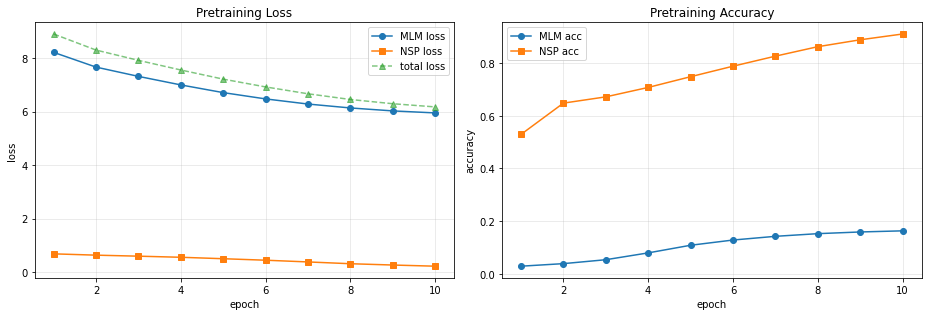

In [12]:
ep = range(1, EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ep, history["mlm_loss"], "o-", label="MLM loss")
ax[0].plot(ep, history["nsp_loss"], "s-", label="NSP loss")
ax[0].plot(ep, history["loss"], "^--", label="total loss", alpha=0.6)
ax[0].set_title("Pretraining Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, history["mlm_acc"], "o-", label="MLM acc")
ax[1].plot(ep, history["nsp_acc"], "s-", label="NSP acc")
ax[1].set_title("Pretraining Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ART, "training_curves.png"), dpi=120)
plt.show()

### 8-2. 정성 평가 — 마스킹된 단어 예측

In [13]:
@torch.no_grad()
def predict_masked(text, n_mask=2):
    model.eval()
    ids = [CLS_ID] + sp.encode(text, out_type=int) + [SEP_ID]
    cand = [i for i, t in enumerate(ids) if t not in SPECIAL_IDS]
    picked = sorted(random.sample(cand, min(n_mask, len(cand))))
    masked = list(ids)
    for i in picked:
        masked[i] = MASK_ID
    seg = torch.zeros(1, len(ids), dtype=torch.long, device=DEVICE)
    inp = torch.tensor([masked], dtype=torch.long, device=DEVICE)
    mlm_logits, _ = model(inp, seg)
    print("입력 :", " ".join(sp.id_to_piece(t) for t in masked))
    for i in picked:
        top = mlm_logits[0, i].topk(5).indices.tolist()
        print(f"  위치 {i}: 정답='{sp.id_to_piece(ids[i])}' -> top5 {[sp.id_to_piece(t) for t in top]}")

for s in ["이 영화는 정말 재미있고 감동적이었다", "배우들의 연기가 훌륭했다", "스토리가 너무 지루하고 별로였다"]:
    predict_masked(s); print()

입력 : [CLS] [MASK] [MASK] ▁정말 ▁재미있고 ▁감동적이 었다 [SEP]
  위치 1: 정답='▁이' -> top5 ['▁정말', '▁아', '▁진짜', '▁이게', '▁너무']
  위치 2: 정답='▁영화는' -> top5 ['▁영화', '점', '▁본', '▁너무', '은']

입력 : [CLS] ▁배우들의 [MASK] [MASK] 했다 [SEP]
  위치 2: 정답='▁연기가' -> top5 ['▁영화', '▁너무', '▁봤습니다', '..', '점']
  위치 3: 정답='▁훌륭' -> top5 ['.', '...', '..', '▁영화', '?']

입력 : [CLS] ▁스토리가 [MASK] ▁지루하고 ▁별로 [MASK] [SEP]
  위치 2: 정답='▁너무' -> top5 ['▁영화', '점', '▁재밌게', '▁너무', '▁본']
  위치 5: 정답='였다' -> top5 ['.', '..', '...', '!', '!!']



### 8-3. NSP 예측 확인

In [14]:
@torch.no_grad()
def predict_nsp(sent_a, sent_b):
    model.eval()
    a, b = sp.encode(sent_a, out_type=int), sp.encode(sent_b, out_type=int)
    tokens = [CLS_ID] + a + [SEP_ID] + b + [SEP_ID]
    seg = [0]*(len(a)+2) + [1]*(len(b)+1)
    inp = torch.tensor([tokens], dtype=torch.long, device=DEVICE)
    sgt = torch.tensor([seg], dtype=torch.long, device=DEVICE)
    _, nsp_logits = model(inp, sgt)
    prob = F.softmax(nsp_logits, dim=-1)[0]
    print(f"A='{sent_a}' | B='{sent_b}' -> IsNext={prob[1]:.2f}, NotNext={prob[0]:.2f}")

predict_nsp("이 영화 정말 최고였어요", "다음에 또 보고 싶어요")
predict_nsp("이 영화 정말 최고였어요", "오늘 점심은 김치찌개였다")

A='이 영화 정말 최고였어요' | B='다음에 또 보고 싶어요' -> IsNext=0.03, NotNext=0.97
A='이 영화 정말 최고였어요' | B='오늘 점심은 김치찌개였다' -> IsNext=0.00, NotNext=1.00


### 8-4. 회고

- **파라미터**: token embedding(8000×96 ≈ 0.77M)이 전체의 대부분을 차지하는 전형적인 tiny-BERT 구조로, 총 **약 1.0M** 파라미터를 달성했습니다.
- **수렴 관찰**: NSP 는 이진 분류라 accuracy 가 비교적 빠르게 올라가지만, MLM 은 8000-way 분류 + 작은 모델·데이터라 loss 가 천천히 내려가고 accuracy 도 낮게 유지됩니다. 과제 안내대로 "모델이 작아 완벽히 수렴하지 않을 수 있음" 을 그대로 관찰할 수 있습니다.
- **배운 점**: MLM 은 특수토큰을 제외한 15% 마스킹(80/10/10), NSP 는 segment/[SEP] 구성이 핵심이며 두 task 를 하나의 시퀀스에서 동시에 학습합니다. `np.memmap` + JSON 메타로 대용량 데이터셋을 메모리 효율적으로 다룰 수 있습니다.
- **개선 방향**: 실제 나무위키 등 대용량 코퍼스, 더 긴 `MAX_LEN`, 더 큰 `d_model`/layer 수, whole-word masking, 더 긴 학습(step) 을 적용하면 MLM 수렴이 개선됩니다. GPU 사용 시 batch/step 을 크게 늘릴 수 있습니다.